# Performance Analysis

This notebook analyzes model performances on each benchmark's capability tree nodes. We'll perform the following analyses:

- Compute pairwise win-rates to see if a single model dominates

## Set Up

Import modules.

In [1]:
import json
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from utils.metrics import winrate
from utils.path import (
    resolve_datasets_dir,
    resolve_eval_results_dir,
    resolve_results_dir,
    resolve_plots_dir,
)

## Preprocessing

Identify all available datasets.

In [2]:
datasets_dir = resolve_datasets_dir()
all_datasets = [d.name for d in datasets_dir.iterdir() if d.is_dir()]

print(f"Found {len(all_datasets)} available datasets:")
for i, dataset in enumerate(all_datasets):
    print(f"{i + 1}: {dataset}")

Found 7 available datasets:
1: Chatbot-Arena
2: CollegeMath
3: DS-1000
4: MATH
5: MMLU
6: ShareGPT10K
7: WildChat10K


Remove datasets that only have evaluation results for one real model.

In [3]:
datasets, removed_datasets = [], []

for dataset in sorted(all_datasets):
    results_dir = resolve_eval_results_dir(dataset)
    num_results = len(list(results_dir.iterdir()))
    print(f"{dataset}: {num_results} models")

    if num_results > 1:
        datasets.append(dataset)
    else:
        removed_datasets.append(dataset)

print(f"{'-' * 100}\nDatasets with multiple real models: {datasets}")
print(f"Removed datasets: {removed_datasets}")

Chatbot-Arena: 1 models
CollegeMath: 3 models
DS-1000: 3 models
MATH: 3 models
MMLU: 3 models
ShareGPT10K: 1 models
WildChat10K: 1 models
----------------------------------------------------------------------------------------------------
Datasets with multiple real models: ['CollegeMath', 'DS-1000', 'MATH', 'MMLU']
Removed datasets: ['Chatbot-Arena', 'ShareGPT10K', 'WildChat10K']


For each remaining dataset, create a DataFrame containing each model's per-instance performance and save it to a CSV file. The rows will be different instances and the columns will be different models.

In [4]:
dataset_to_df = {}

for dataset in datasets:
    csv_path = resolve_results_dir() / f"{dataset}.csv"
    if csv_path.exists():
        print(f"Skipping {dataset} because it already exists")
        dataset_to_df[dataset] = pd.read_csv(csv_path)
        continue

    models_dir = resolve_eval_results_dir(dataset)

    data = {}
    for model in models_dir.iterdir():
        results_file = model / "results.json"
        if not model.is_dir() or not results_file.exists():
            continue

        with open(results_file) as f:
            data[model.name] = json.load(f)

    df = pd.DataFrame(data)
    print(f"{dataset}: {len(df)} instances")
    display(df.head())

    df.to_csv(csv_path, index=False)
    print(f"Saved {dataset}'s performance matrix to {csv_path}\n{'-' * 100}")
    dataset_to_df[dataset] = df

Skipping CollegeMath because it already exists
Skipping DS-1000 because it already exists
Skipping MATH because it already exists
Skipping MMLU because it already exists


View each DataFrame.

In [5]:
for dataset, df in dataset_to_df.items():
    print(f"{dataset}: {len(df)} instances")
    display(df.head())

CollegeMath: 2818 instances


,dart-math-llama3-8b-uniform,gpt-4o-mini-2024-07-18,Llama-3.1-8B-Instruct
0,1,1,1
1,1,1,0
2,0,1,1
3,1,1,1
4,0,1,1


DS-1000: 1000 instances


,deepseek-coder-6.7b-base,gpt-3.5-turbo-0613,gpt-4o-2024-08-06
0,1,0,0
1,0,1,1
2,1,0,1
3,1,1,1
4,0,1,0


MATH: 5000 instances


,dart-math-llama3-8b-uniform,gpt-4o-mini-2024-07-18,Llama-3.1-8B-Instruct
0,1,1,1
1,1,1,1
2,0,1,0
3,1,1,1
4,1,1,1


MMLU: 14042 instances


,gpt-4o-mini-2024-07-18,Llama-3.1-8B-Instruct,Llama-3.1-Tulu-3-8B
0,1,1,1
1,0,1,0
2,0,1,0
3,0,0,0
4,1,1,1


## Win-Rate Analysis

### Overall

For each dataset, compute each model's mean accuracy across all instances.

Saved plot to C:\Users\Mike\vscode\EvalTree\Plots\all\mean_accuracies.png


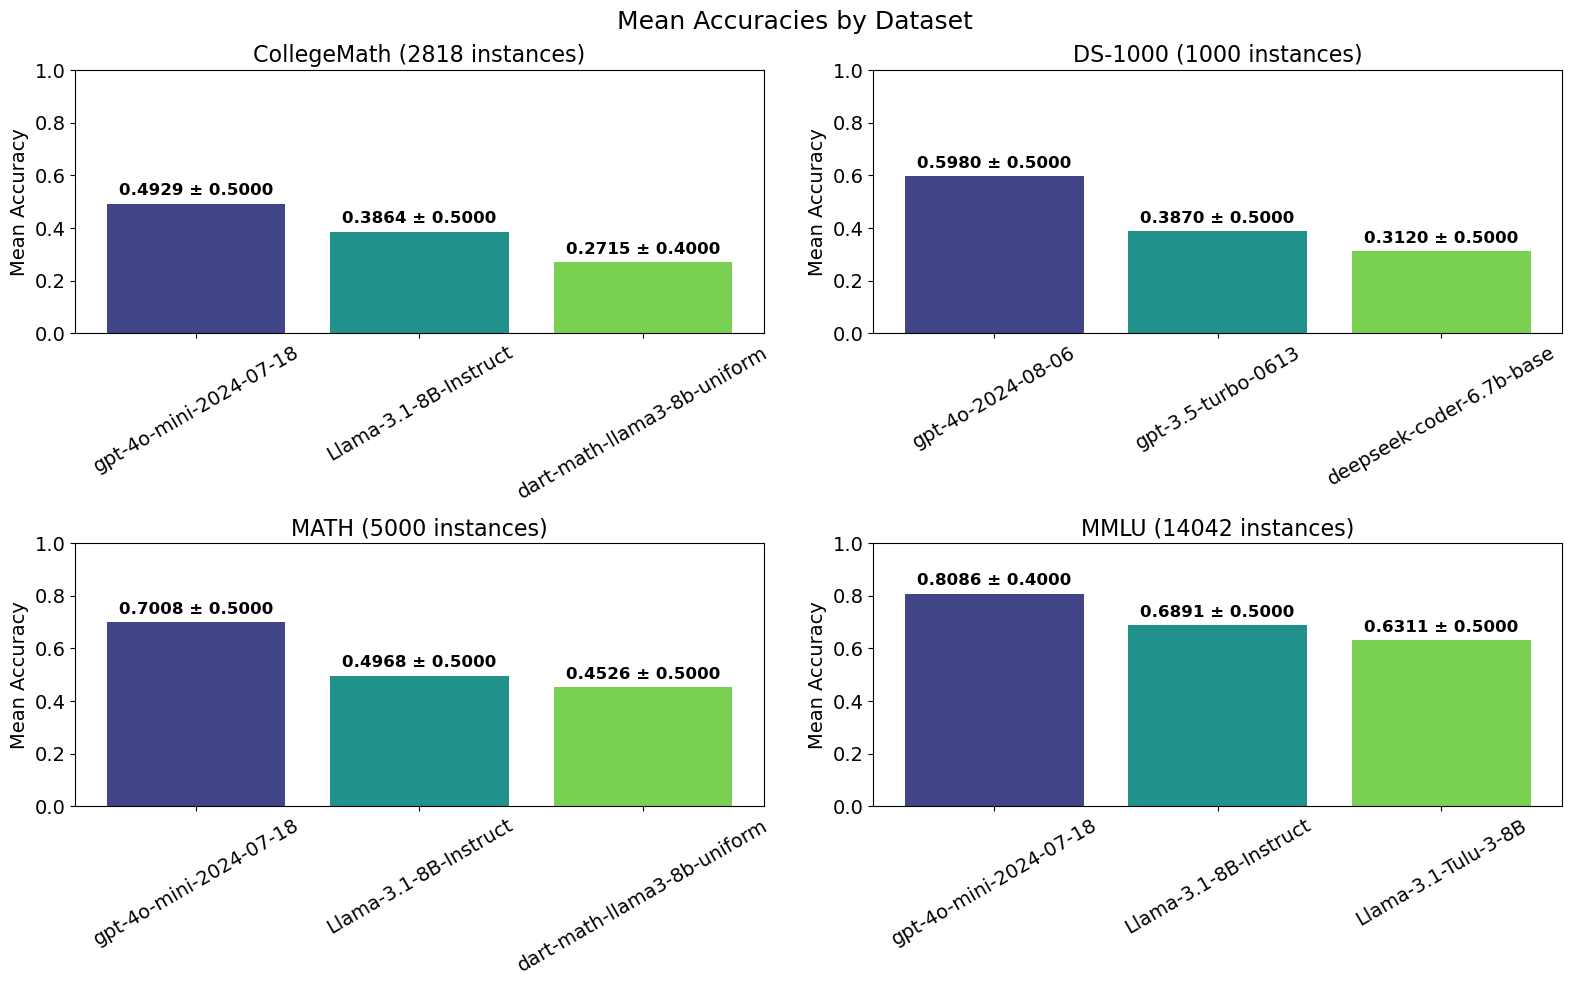

In [ ]:
nrows = len(datasets) // 2
ncols = nrows
figsize = (16, 10)
label_rotation = 30
label_fontsize = 14
title_fontsize = 16
annotation_fontsize = 12
suptitle_fontsize = 18

fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
axes = axes.flatten()

for idx, (dataset, df) in enumerate(dataset_to_df.items()):
    ax = axes[idx]
    mean_accuracies = df.mean().sort_values(ascending=False)
    std_accuracies = df.std()[mean_accuracies.index]

    # Plot mean accuracies
    bars = ax.bar(
        range(len(mean_accuracies)),
        mean_accuracies.values,
        color=plt.cm.viridis(np.linspace(0.2, 0.8, len(mean_accuracies))),
    )

    # Styling
    ax.set_xticks(range(len(mean_accuracies)))
    ax.tick_params(axis="both", labelsize=label_fontsize)
    ax.set_xticklabels(mean_accuracies.index, rotation=label_rotation)
    ax.set_ylabel("Mean Accuracy", fontsize=label_fontsize)
    ax.set_title(f"{dataset} ({len(df)} instances)", fontsize=title_fontsize)
    ax.set_ylim(0, 1)

    # Add mean ± std labels on bars
    zipped = zip(bars, mean_accuracies.values, std_accuracies.values)
    for bar, mean_val, std_val in zipped:
        # Round std to 1 sig fig, format with same decimal places as mean
        ndigits = -int(np.floor(np.log10(abs(std_val))))
        std_rounded = round(std_val, ndigits) if std_val > 0 else 0

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.02,
            f"{mean_val:.4f} ± {std_rounded:.4f}",
            ha="center",
            va="bottom",
            fontsize=annotation_fontsize,
            fontweight="bold",
        )

plt.suptitle("Mean Accuracies by Dataset", fontsize=suptitle_fontsize)
plt.tight_layout()

out_path = resolve_plots_dir() / "All" / "mean_accuracies.png"
out_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(out_path)

print(f"Saved plot to {out_path}")
plt.show()

**Observations**
- CollegeMath:
  - There's a clear global ranking, but the performance gap of ~10 accuracy points between each model doesn't seem too large
- DS-1000:
  - GPT-3.5-Turbo seems better than DeepSeek-Coder by ~6 accuracy points
  - However, GPT-4o-mini beats both of them ~20-30 accuracy points
- MATH:
  - Llama-3.1-8B-Instruct and DART-Math-Llama only differ by ~4 accuracy points
  - However, GPT-4o-mini beats both of them by ~20-25 accuracy points
- MMLU:
  - Llama-3.1-8B-Instruct and Llama-3.1-Tulu-8B only differ by ~6 accuracy points
  - However,  GPT-4o-mini beats both of them by ~10-15 accuracy points

**Analysis**
- Across all benchmarks, GPT-4o-mini is consistently the best model across all instances by ~10-30 accuracy points
- GPT-4o-mini's competitors typically have similar overall performances to each other, differing by ~5-10 accuracy points

For each dataset, create a pairwise win-rate matrix $P$ where $p_{ij}$ denotes the probability that model $M_i$ beats model $M_j$ across all instances in the dataset.

Saved plot to C:\Users\Mike\vscode\EvalTree\Plots\CollegeMath\overall_winrate_matrix.png
----------------------------------------------------------------------------------------------------


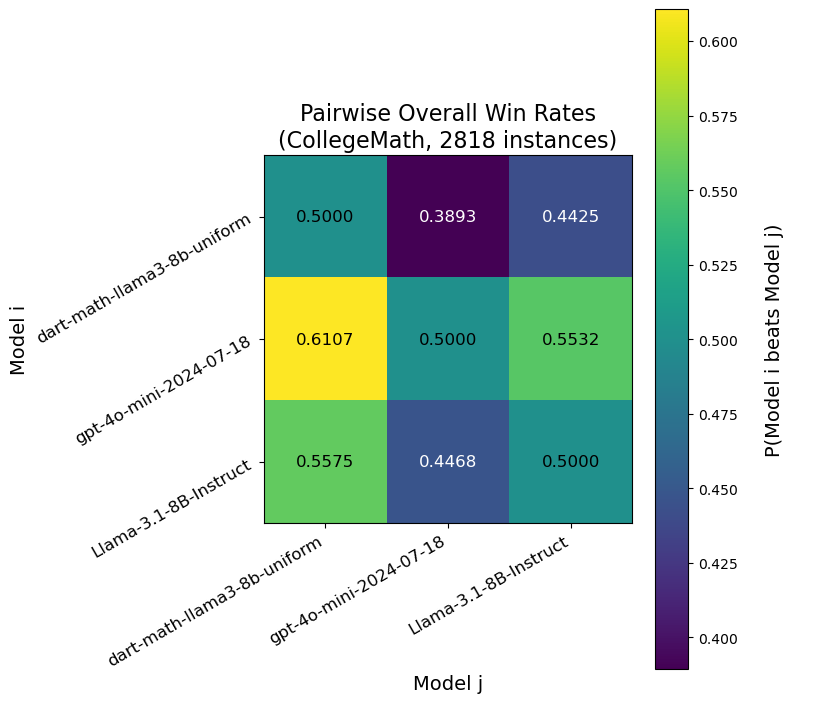

Saved plot to C:\Users\Mike\vscode\EvalTree\Plots\DS-1000\overall_winrate_matrix.png
----------------------------------------------------------------------------------------------------


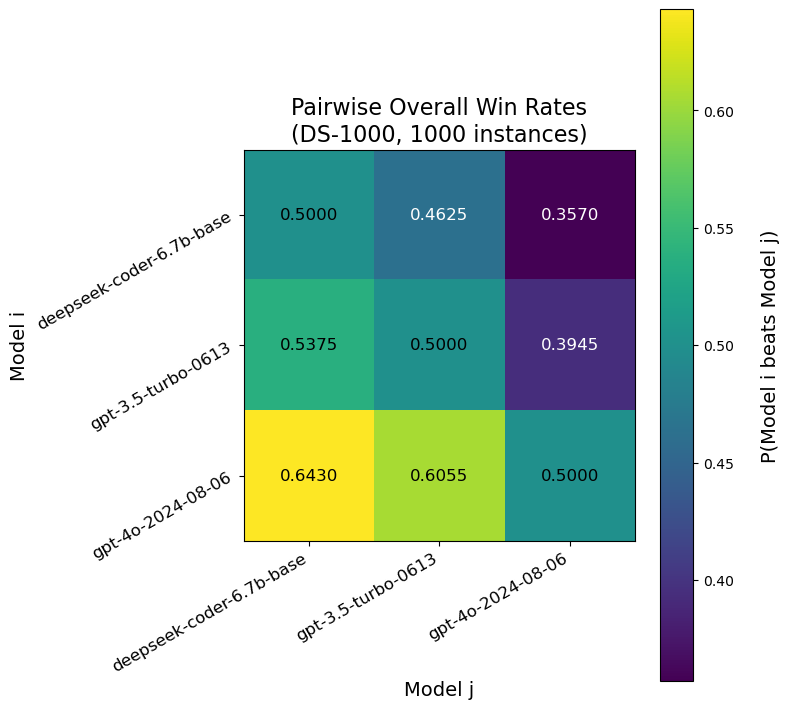

Saved plot to C:\Users\Mike\vscode\EvalTree\Plots\MATH\overall_winrate_matrix.png
----------------------------------------------------------------------------------------------------


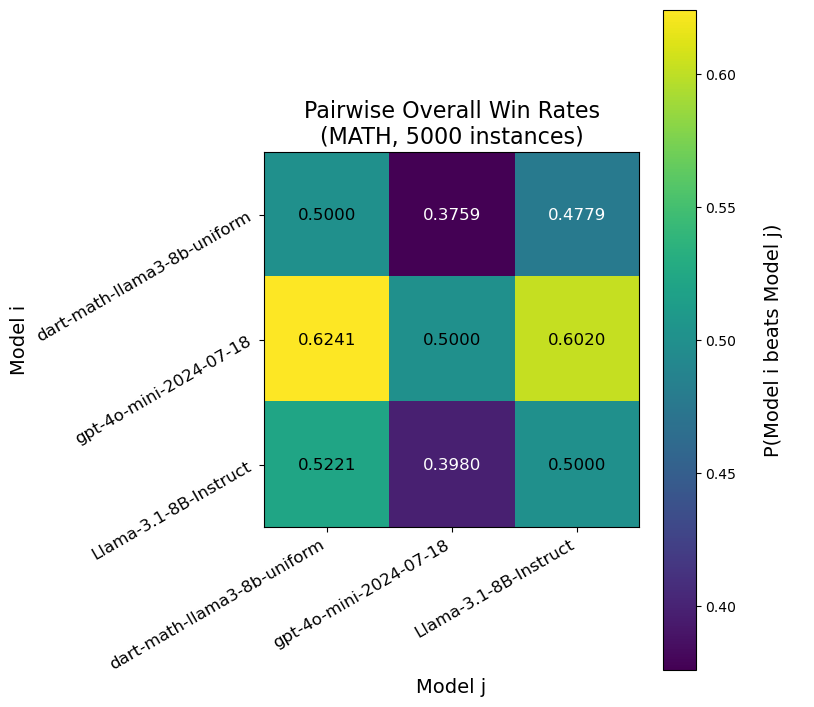

Saved plot to C:\Users\Mike\vscode\EvalTree\Plots\MMLU\overall_winrate_matrix.png
----------------------------------------------------------------------------------------------------


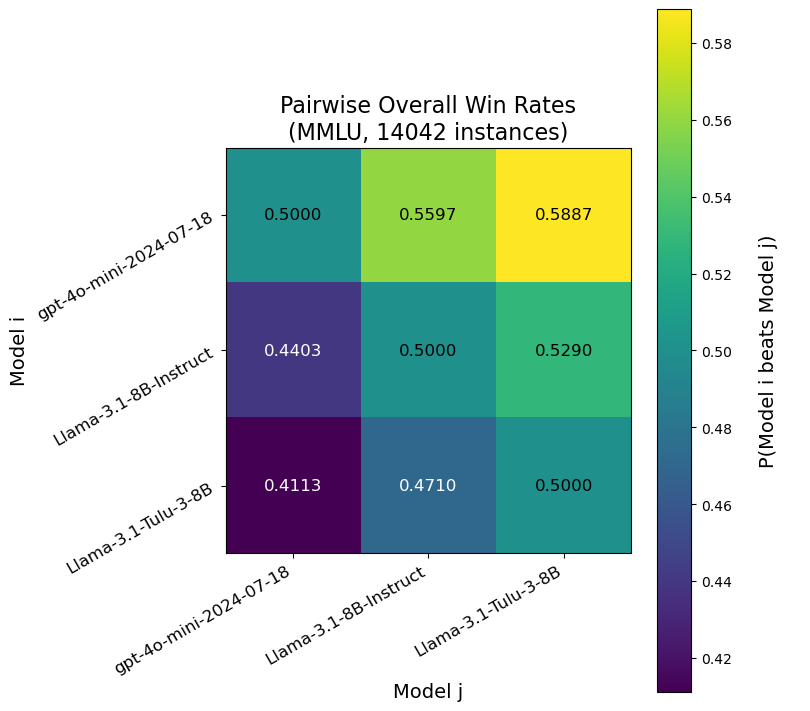

In [35]:
figsize = (8, 8)
label_rotation = 30
annotation_fontsize = 12
tick_fontsize = annotation_fontsize
label_fontsize = 14
title_fontsize = 16


for dataset, df in dataset_to_df.items():
    models, num_models = df.columns, len(df.columns)
    winrate_matrix = np.zeros((num_models, num_models), dtype=float)
    std_matrix = np.zeros((num_models, num_models), dtype=float)

    # Compute pairwise win rates
    for i, model_i in enumerate(models):
        for j, model_j in enumerate(models):
            scores_i, scores_j = df[model_i], df[model_j]
            winrate_matrix[i, j] = (
                0.5 if i == j else winrate(scores_i, scores_j, include_ties=True)
            )

    winrate_df = pd.DataFrame(winrate_matrix, index=models, columns=models)

    plt.figure(figsize=figsize)
    im = plt.imshow(winrate_df.values)

    # Add text annotations with win rate
    for i in range(num_models):
        for j in range(num_models):
            wr = winrate_df.values[i, j]
            text_color = "white" if wr < 0.5 else "black"
            plt.text(
                j,
                i,
                f"{wr:.4f}",
                ha="center",
                va="center",
                color=text_color,
                fontsize=annotation_fontsize,
            )

    plt.tick_params(axis="both", labelsize=tick_fontsize)
    plt.xticks(
        range(len(winrate_df.columns)),
        winrate_df.columns,
        rotation=label_rotation,
        ha="right",
    )
    plt.yticks(
        range(len(winrate_df.index)),
        winrate_df.index,
        rotation=label_rotation,
        ha="right",
    )
    plt.title(
        f"Pairwise Overall Win Rates\n({dataset}, {len(df)} instances)",
        fontsize=title_fontsize,
    )
    plt.xlabel("Model j", fontsize=label_fontsize)
    plt.ylabel("Model i", fontsize=label_fontsize)

    cbar = plt.colorbar(im)
    cbar.set_label(
        "\nP(Model i beats Model j)\n",
        fontsize=label_fontsize,
    )
    plt.tight_layout()

    out_path = resolve_plots_dir() / dataset / "overall_winrate_matrix.png"
    out_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(out_path)
    print(f"Saved plot to {out_path}\n{'-' * 100}")
    plt.show()

**Observations**
- Across each dataset, it looks like GPT-4o has the highest win-rate, and the overall ordering appears to be transitive
- E.g., for CollegeMath, the overall ordering is GPT-4o-mini > Llama-3.1-8B-Instruct > DART

**Analysis**
- Because each dataset's overall ordering seems transitive, it may be the case that if we slice the dataset by EvalTree's nodes, each node's Kendall's $\tau$ will be similar to the global Kendall's $\tau$
- Using Kendall's $\tau$ to identify capabilities might not work if one model dominates